# Difference in Differences with `pymc` models

:::{note}
This example is in-progress! Further elaboration and explanation will follow soon.
:::

In [1]:
import arviz_plots as azp

import causalpy as cp

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'
seed = 42

## Load data

In [3]:
df = cp.load_data("did")
df.head()

,group,t,unit,post_treatment,y
0,0,0.0,0,False,0.977736
1,0,1.0,0,True,2.132566
2,1,0.0,1,False,1.192903
3,1,1.0,1,True,2.816825
4,0,0.0,2,False,1.114538


## Run the analysis

:::{note}
The `random_seed` keyword argument for the PyMC sampler is not necessary. We use it here so that the results are reproducible.
:::

In [4]:
result = cp.DifferenceInDifferences(
    df,
    formula="y ~ 1 + group*post_treatment",
    time_variable_name="t",
    group_variable_name="group",
    model=cp.pymc_models.LinearRegression(sample_kwargs={"random_seed": seed}),
).fit()

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


...

Sampling: [y_hat]


Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


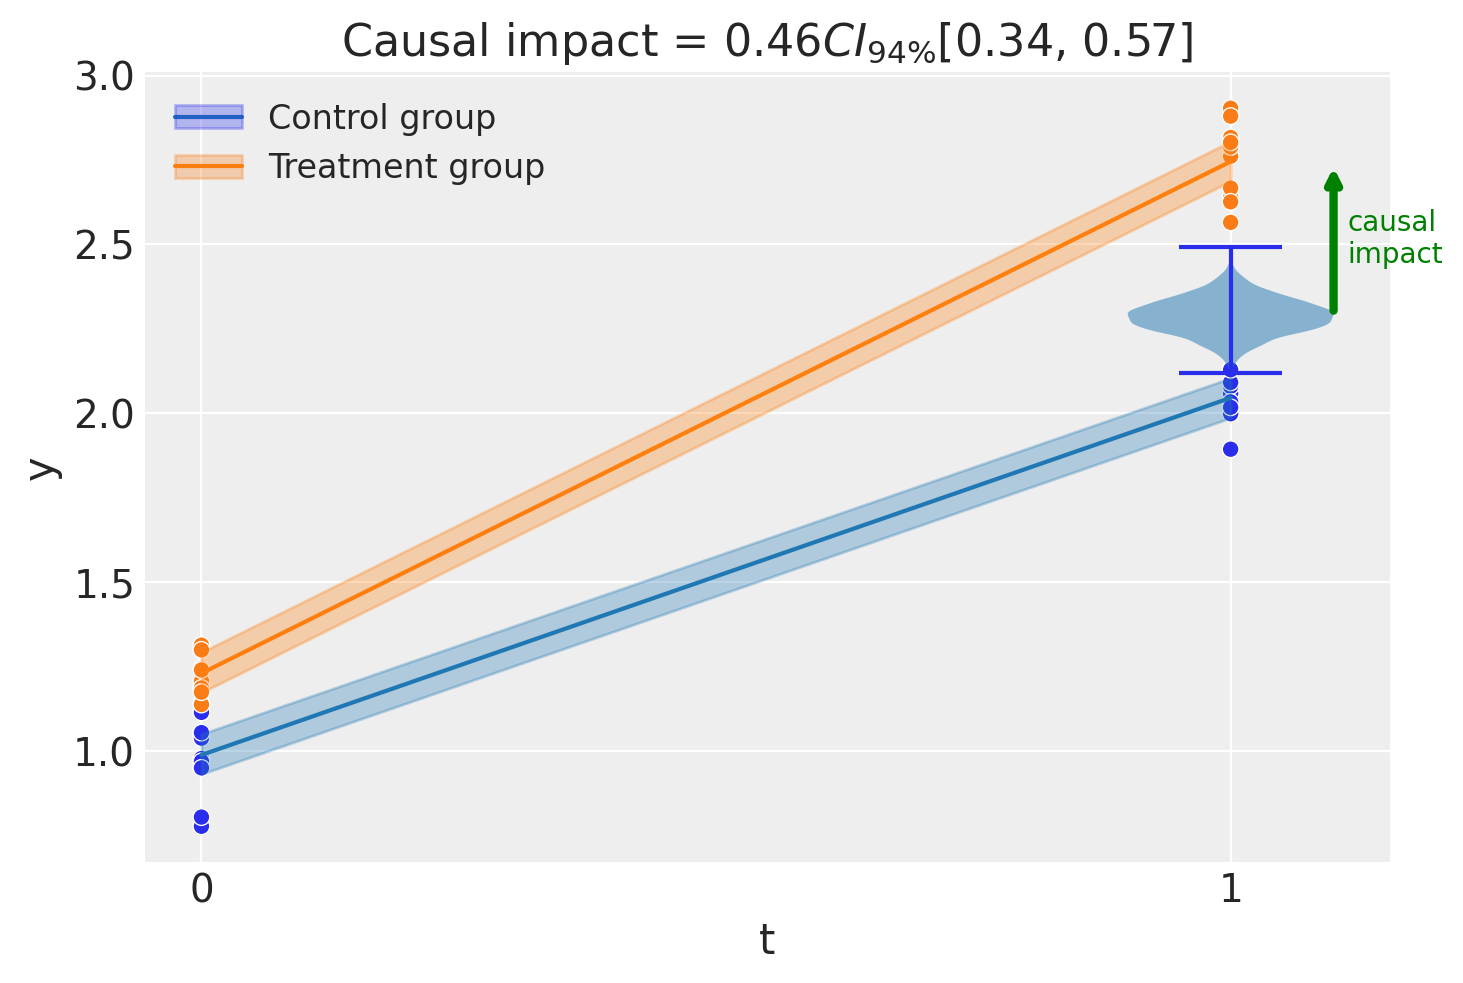

In [5]:
fig, ax = result.plot()

In [6]:
result.summary()

===========================Difference in Differences============================
Formula: y ~ 1 + group*post_treatment

Results:
Causal impact = 0.46$CI_{94\%}$[0.34, 0.57]
Model coefficients:
  Intercept                     0.99, 94% HDI [0.93, 1.1]
  post_treatment[T.True]        1.1, 94% HDI [0.98, 1.1]
  group                         0.24, 94% HDI [0.16, 0.33]
  group:post_treatment[T.True]  0.46, 94% HDI [0.34, 0.57]


We can get nicely formatted tables from our integration with the [maketables](https://github.com/py-econometrics/maketables) package.

In [7]:
from maketables import ETable

result.set_maketables_options(hdi_prob=0.95)
ETable(result, coef_fmt="b:.3f \n [ci95l:.3f, ci95u:.3f]")

<maketables.mtable.MTable.__repr__.<locals>.DualOutput at 0x15c29bcb0>

In [8]:
impact = result.result.causal_impact.rename("causal_impact").to_dataset()
posterior_plot = azp.plot_dist(
    impact,
    group=None,
    ci_kind="hdi",
    ci_prob=0.94,
    figure_kwargs={"figsize": (7, 4)},
)
ax = posterior_plot.get_target("causal_impact", {})
ax.axvline(0, color="C3", linestyle="--")
ax.set(xlabel="Causal impact")
posterior_plot.add_title("Posterior estimate of causal impact");

## Effect Summary Reporting

For decision-making, you often need a concise summary of the causal effect. The `effect_summary()` method provides a decision-ready report with key statistics. Note that for Difference-in-Differences, the effect is a single scalar (average treatment effect), unlike time-series experiments where effects vary over time.


In [9]:
# Generate effect summary
stats = result.effect_summary()
stats.table

,mean,median,hdi_lower,hdi_upper,p_gt_0
treatment_effect,0.457947,0.458376,0.337855,0.577837,1.0


In [10]:
print(stats.text)

The average treatment effect was 0.46 (95% HDI [0.34, 0.58]). The posterior probability of an increase is 1.000.


You can customize the summary with different directions and ROPE thresholds:

- **Direction**: Test for increase, decrease, or two-sided effect
- **Alpha**: Set the HDI confidence level (default 95%)
- **ROPE**: Specify a minimal effect size threshold


In [11]:
# Example: Two-sided test with ROPE
stats = result.effect_summary(
    direction="two-sided",
    alpha=0.05,
    min_effect=0.3,  # Region of Practical Equivalence
)
stats.table

,mean,median,hdi_lower,hdi_upper,p_two_sided,prob_of_effect,p_rope
treatment_effect,0.457947,0.458376,0.337855,0.577837,0.0,1.0,0.99525


In [12]:
print("\n" + stats.text)


The average treatment effect was 0.46 (95% HDI [0.34, 0.58]). The two-sided tail probability is 0.000. Using the closed ROPE [-0.3, 0.3], the 95% HDI is entirely outside the ROPE; the effect is practically significant. Posterior mass is 0.000 below, 0.005 inside, and 0.995 above the ROPE.
